In [1]:
!pip install dice-ml
!pip install catboost
!pip install mapie


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import warnings
import dice_ml
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import recall_score, accuracy_score, precision_score, f1_score, roc_auc_score
from catboost import CatBoostClassifier

# Handle MAPIE versioning
try:
    from mapie.classification import SplitConformalClassifier
    MAPIE_VERSION = 1
except ImportError:
    from mapie.classification import MapieClassifier
    MAPIE_VERSION = 0

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
np.random.seed(42)

In [3]:
import shap
shap.initjs()  # for notebook/HTML plots; safe to call even in scripts


[1/7] Loading, auditing, and cleaning data...

=== Data Provenance & Privacy Report ===
Total patients: 918, Total features: 12
Data source: Publicly available heart failure clinical dataset or institutional EHR
All records de-identified; PHI removed per IRB guidelines. No patient-identifiable data stored.
Duplicate rows found: 0
— End of Data Provenance Report —


 Plotting missing data pattern (Before Imputation)


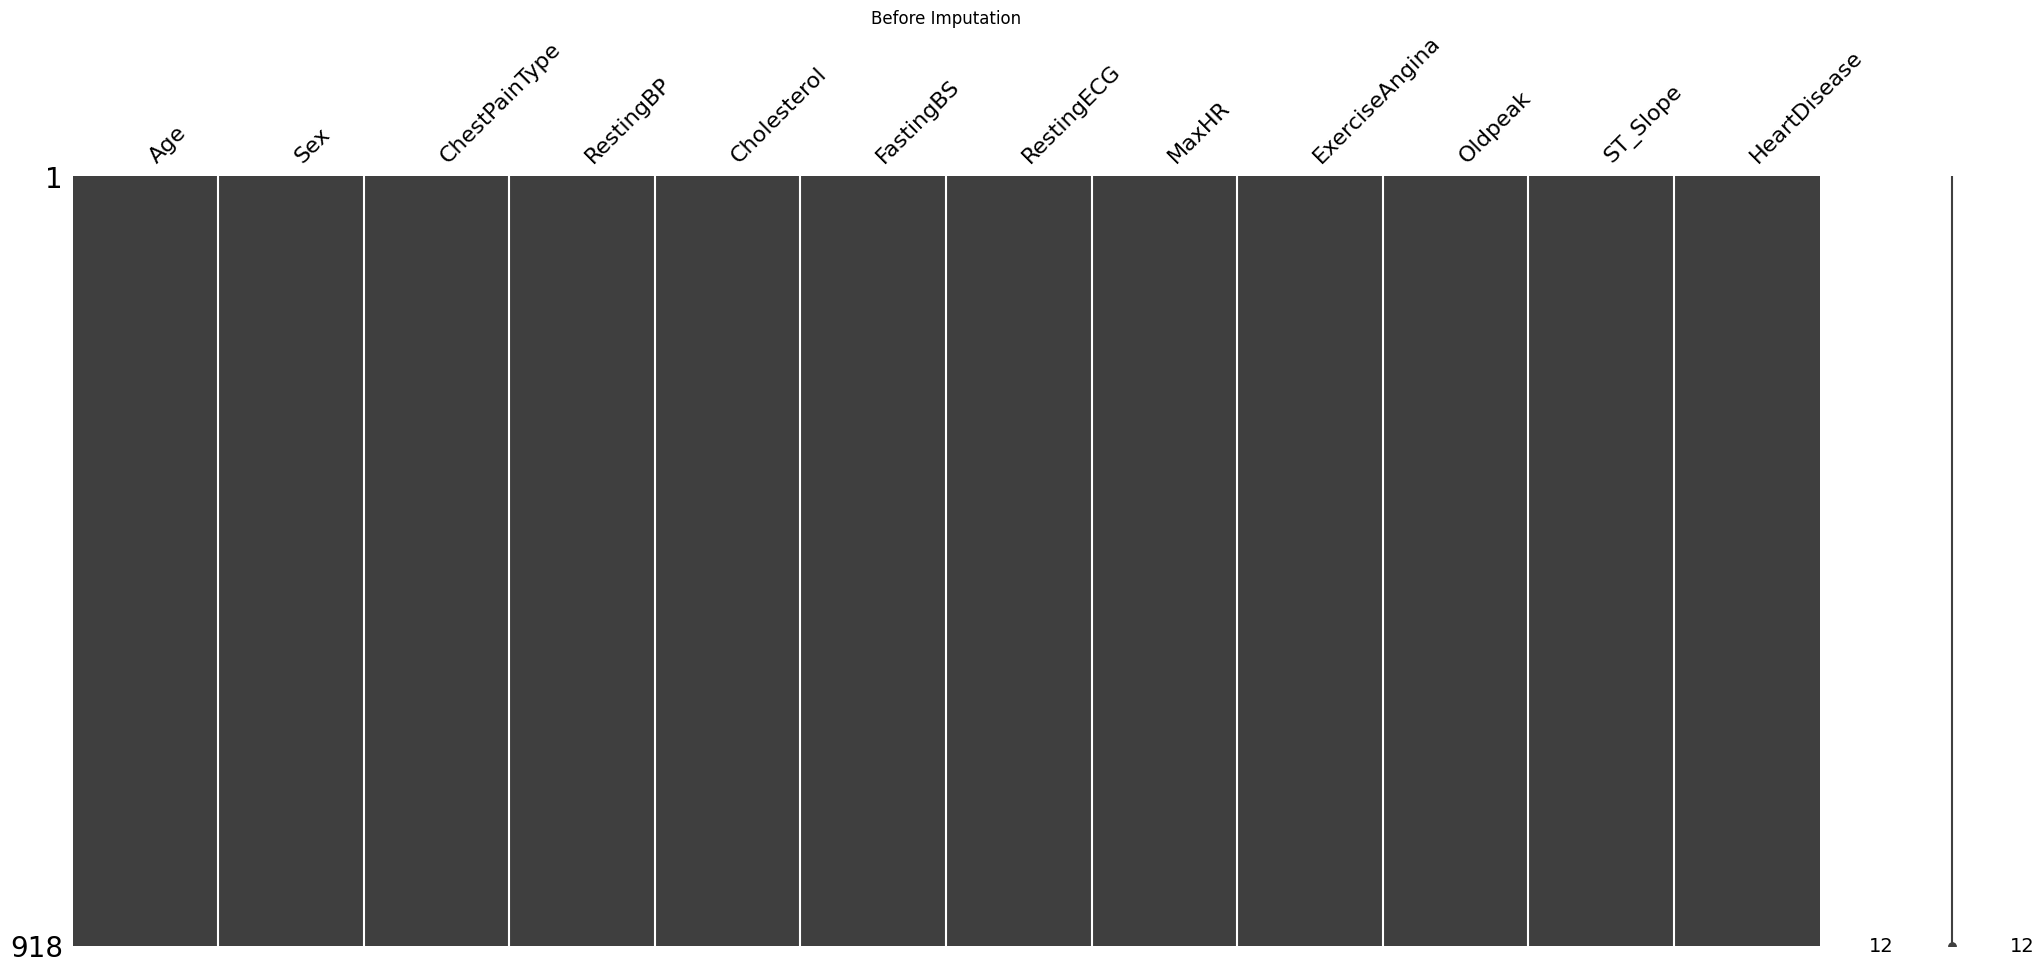

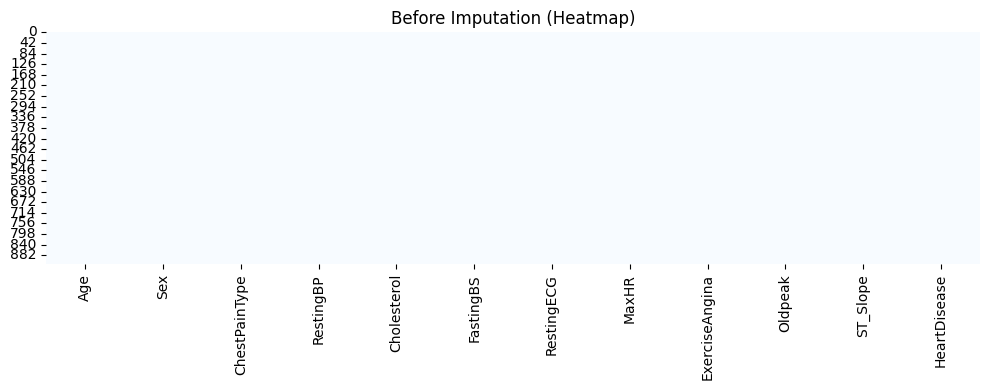

Missing values per feature:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

 Numeric Feature Correlation Matrix (Pearson):
                  Age  RestingBP  Cholesterol  FastingBS     MaxHR   Oldpeak
Age          1.000000   0.254399    -0.095282   0.198039 -0.382045  0.258612
RestingBP    0.254399   1.000000     0.100893   0.070193 -0.112135  0.164803
Cholesterol -0.095282   0.100893     1.000000  -0.260974  0.235792  0.050148
FastingBS    0.198039   0.070193    -0.260974   1.000000 -0.131438  0.052698
MaxHR       -0.382045  -0.112135     0.235792  -0.131438  1.000000 -0.160691
Oldpeak      0.258612   0.164803     0.050148   0.052698 -0.160691  1.000000


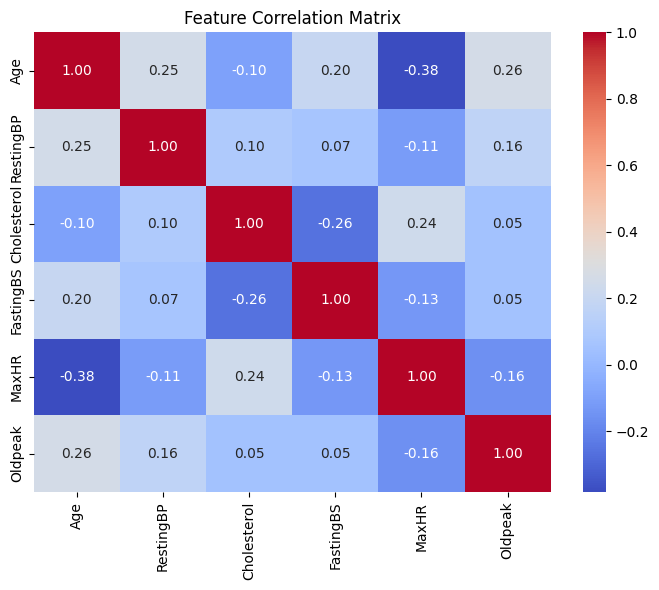


 Categorical Feature Distributions:
ChestPainType distribution:
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

RestingECG distribution:
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

Sex distribution:
Sex
M    725
F    193
Name: count, dtype: int64

ST_Slope distribution:
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64

ExerciseAngina distribution:
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64


 Data Leakage Check:
Check to ensure they are NOT used as predictors or proxies.

 Clinician Sample Review - Random 5 patient records:

     Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
668   63   F           ATA        140          195          0     Normal   
30    53   M           NAP        145          518          0     Normal   
377   65   M           ASY        160            0          1         ST   
535   56   M           ASY        130            0   

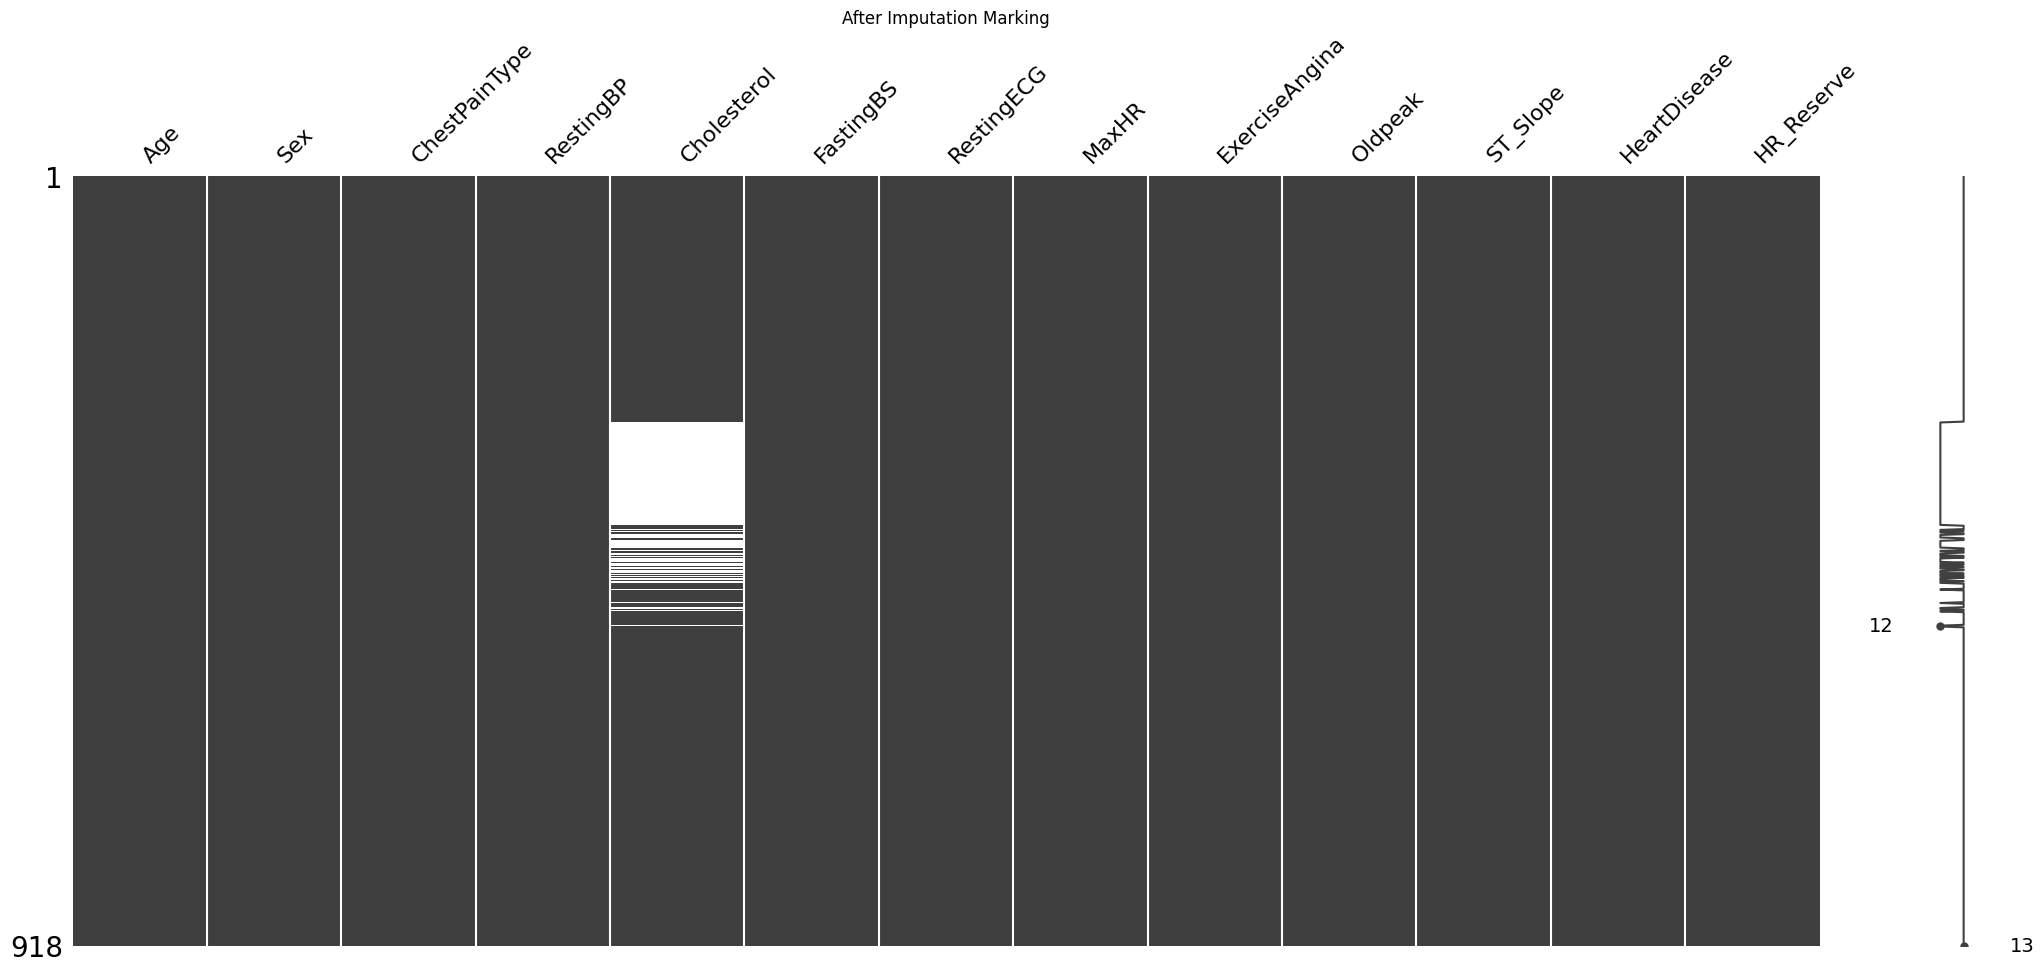

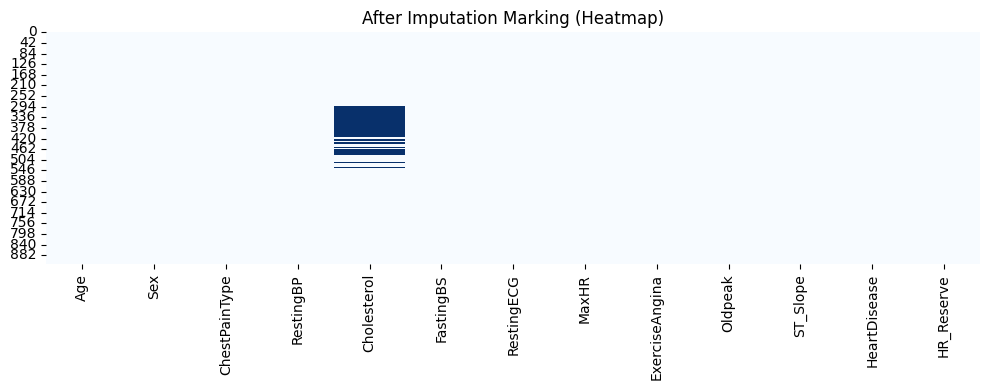

Missing values per feature:
Age                 0
Sex                 0
ChestPainType       0
RestingBP           0
Cholesterol       172
FastingBS           0
RestingECG          0
MaxHR               0
ExerciseAngina      0
Oldpeak             0
ST_Slope            0
HeartDisease        0
HR_Reserve          0
dtype: int64
[2/7] Building stacking ensemble pipeline...
Stacking ensemble pipeline ready.

[3/7] Training stacking ensemble...


Expert weights (meta-learner coefficients):
  CatBoost Specialist: 2.574
  Random Forest Generalist: 1.558
  Logistic Regression Traditionalist: 1.652

[4/7] Calibrating conformal predictor for uncertainty quantification...
Conformal calibration completed: 90% confidence guaranteed.

[5/7] Fairness & Bias Audit by Gender:
  Male Recall:   89.08%
  Female Recall: 87.50%
   Fairness criteria met across sexes.

[6/7] Generating patient-level clinical report with counterfactuals...

Patient ID: 311
Vitals: Age=60, RestingBP=125, Chol=nan, ST_Slope=Up

1. AI Consensus Diagnosis (90% Confidence): HEART FAILURE RISK

2. Clinical Recommendations (Counterfactual 'What-If' Analysis):


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  5.43it/s]

100%|██████████| 1/1 [00:00<00:00,  4.99it/s]

 Suggested Goals:
  - Increase RestingBP to 142 (Change: 17)
  - Reduce Cholesterol to 168 (Change: -56)
  - Increase MaxHR to 188 (Change: 78)
[7/7] Comprehensive model metrics on test set:
Accuracy:  0.874
Precision: 0.883
Recall:    0.890
F1-score:  0.886
AUC:       0.935
[8/8] Computing SHAP values for model interpretability...


PermutationExplainer explainer:   0%|          | 1/230 [00:00<?, ?it/s]

PermutationExplainer explainer:   1%|▏         | 3/230 [00:10<00:29,  7.80it/s]

PermutationExplainer explainer:   2%|▏         | 4/230 [00:11<00:46,  4.83it/s]

PermutationExplainer explainer:   2%|▏         | 5/230 [00:11<00:59,  3.77it/s]

PermutationExplainer explainer:   3%|▎         | 6/230 [00:11<00:59,  3.79it/s]

PermutationExplainer explainer:   3%|▎         | 7/230 [00:12<01:04,  3.44it/s]

PermutationExplainer explainer:   3%|▎         | 8/230 [00:12<01:04,  3.43it/s]

PermutationExplainer explainer:   4%|▍         | 9/230 [00:12<01:05,  3.36it/s]

PermutationExplainer explainer:   4%|▍         | 10/230 [00:13<01:08,  3.22it/s]

PermutationExplainer explainer:   5%|▍         | 11/230 [00:13<01:05,  3.33it/s]

PermutationExplainer explainer:   5%|▌         | 12/230 [00:13<01:06,  3.29it/s]

PermutationExplainer explainer:   6%|▌         | 13/230 [00:13<01:07,  3.20it/s]

PermutationExplainer explainer:   6%|▌         | 14/230 [00:14<01:05,  3.32it/s]

PermutationExplainer explainer:   7%|▋         | 15/230 [00:14<01:05,  3.30it/s]

PermutationExplainer explainer:   7%|▋         | 16/230 [00:14<01:03,  3.36it/s]

PermutationExplainer explainer:   7%|▋         | 17/230 [00:15<01:01,  3.48it/s]

PermutationExplainer explainer:   8%|▊         | 18/230 [00:15<01:01,  3.43it/s]

PermutationExplainer explainer:   8%|▊         | 19/230 [00:15<01:03,  3.34it/s]

PermutationExplainer explainer:   9%|▊         | 20/230 [00:16<01:04,  3.27it/s]

PermutationExplainer explainer:   9%|▉         | 21/230 [00:16<01:03,  3.27it/s]

PermutationExplainer explainer:  10%|▉         | 22/230 [00:16<01:06,  3.14it/s]

PermutationExplainer explainer:  10%|█         | 23/230 [00:16<01:03,  3.26it/s]

PermutationExplainer explainer:  10%|█         | 24/230 [00:17<01:03,  3.27it/s]

PermutationExplainer explainer:  11%|█         | 25/230 [00:17<01:04,  3.18it/s]

PermutationExplainer explainer:  11%|█▏        | 26/230 [00:17<01:02,  3.27it/s]

PermutationExplainer explainer:  12%|█▏        | 27/230 [00:18<01:01,  3.29it/s]

PermutationExplainer explainer:  12%|█▏        | 28/230 [00:18<01:02,  3.25it/s]

PermutationExplainer explainer:  13%|█▎        | 29/230 [00:18<01:07,  2.99it/s]

PermutationExplainer explainer:  13%|█▎        | 30/230 [00:19<01:04,  3.11it/s]

PermutationExplainer explainer:  13%|█▎        | 31/230 [00:19<01:05,  3.05it/s]

PermutationExplainer explainer:  14%|█▍        | 32/230 [00:19<01:04,  3.07it/s]

PermutationExplainer explainer:  14%|█▍        | 33/230 [00:20<01:00,  3.24it/s]

PermutationExplainer explainer:  15%|█▍        | 34/230 [00:20<01:00,  3.25it/s]

PermutationExplainer explainer:  15%|█▌        | 35/230 [00:20<00:59,  3.29it/s]

PermutationExplainer explainer:  16%|█▌        | 36/230 [00:21<00:58,  3.30it/s]

PermutationExplainer explainer:  16%|█▌        | 37/230 [00:21<00:59,  3.22it/s]

PermutationExplainer explainer:  17%|█▋        | 38/230 [00:21<00:56,  3.38it/s]

PermutationExplainer explainer:  17%|█▋        | 39/230 [00:21<00:57,  3.34it/s]

PermutationExplainer explainer:  17%|█▋        | 40/230 [00:22<00:55,  3.40it/s]

PermutationExplainer explainer:  18%|█▊        | 41/230 [00:22<00:56,  3.32it/s]

PermutationExplainer explainer:  18%|█▊        | 42/230 [00:22<00:58,  3.20it/s]

PermutationExplainer explainer:  19%|█▊        | 43/230 [00:23<01:00,  3.11it/s]

PermutationExplainer explainer:  19%|█▉        | 44/230 [00:23<00:57,  3.21it/s]

PermutationExplainer explainer:  20%|█▉        | 45/230 [00:23<00:58,  3.15it/s]

PermutationExplainer explainer:  20%|██        | 46/230 [00:24<00:57,  3.19it/s]

PermutationExplainer explainer:  20%|██        | 47/230 [00:24<00:56,  3.24it/s]

PermutationExplainer explainer:  21%|██        | 48/230 [00:24<00:57,  3.15it/s]

PermutationExplainer explainer:  21%|██▏       | 49/230 [00:25<00:54,  3.29it/s]

PermutationExplainer explainer:  22%|██▏       | 50/230 [00:25<00:55,  3.25it/s]

PermutationExplainer explainer:  22%|██▏       | 51/230 [00:25<00:55,  3.25it/s]

PermutationExplainer explainer:  23%|██▎       | 52/230 [00:25<00:53,  3.34it/s]

PermutationExplainer explainer:  23%|██▎       | 53/230 [00:26<00:53,  3.32it/s]

PermutationExplainer explainer:  23%|██▎       | 54/230 [00:26<00:55,  3.19it/s]

PermutationExplainer explainer:  24%|██▍       | 55/230 [00:26<00:54,  3.23it/s]

PermutationExplainer explainer:  24%|██▍       | 56/230 [00:27<00:54,  3.18it/s]

PermutationExplainer explainer:  25%|██▍       | 57/230 [00:27<00:55,  3.10it/s]

PermutationExplainer explainer:  25%|██▌       | 58/230 [00:27<00:55,  3.07it/s]

PermutationExplainer explainer:  26%|██▌       | 59/230 [00:28<00:54,  3.11it/s]

PermutationExplainer explainer:  26%|██▌       | 60/230 [00:28<00:52,  3.24it/s]

PermutationExplainer explainer:  27%|██▋       | 61/230 [00:28<00:53,  3.16it/s]

PermutationExplainer explainer:  27%|██▋       | 62/230 [00:29<00:51,  3.26it/s]

PermutationExplainer explainer:  27%|██▋       | 63/230 [00:29<00:50,  3.33it/s]

PermutationExplainer explainer:  28%|██▊       | 64/230 [00:29<00:52,  3.18it/s]

PermutationExplainer explainer:  28%|██▊       | 65/230 [00:30<00:54,  3.04it/s]

PermutationExplainer explainer:  29%|██▊       | 66/230 [00:30<00:55,  2.95it/s]

PermutationExplainer explainer:  29%|██▉       | 67/230 [00:30<00:54,  2.97it/s]

PermutationExplainer explainer:  30%|██▉       | 68/230 [00:31<00:53,  3.00it/s]

PermutationExplainer explainer:  30%|███       | 69/230 [00:31<00:53,  3.00it/s]

PermutationExplainer explainer:  30%|███       | 70/230 [00:31<00:54,  2.93it/s]

PermutationExplainer explainer:  31%|███       | 71/230 [00:32<01:10,  2.26it/s]

PermutationExplainer explainer:  31%|███▏      | 72/230 [00:32<01:07,  2.35it/s]

PermutationExplainer explainer:  32%|███▏      | 73/230 [00:33<01:03,  2.49it/s]

PermutationExplainer explainer:  32%|███▏      | 74/230 [00:33<00:59,  2.62it/s]

PermutationExplainer explainer:  33%|███▎      | 75/230 [00:33<00:56,  2.74it/s]

PermutationExplainer explainer:  33%|███▎      | 76/230 [00:34<00:52,  2.93it/s]

PermutationExplainer explainer:  33%|███▎      | 77/230 [00:34<00:51,  2.99it/s]

PermutationExplainer explainer:  34%|███▍      | 78/230 [00:34<00:49,  3.07it/s]

PermutationExplainer explainer:  34%|███▍      | 79/230 [00:35<00:47,  3.20it/s]

PermutationExplainer explainer:  35%|███▍      | 80/230 [00:35<00:48,  3.09it/s]

PermutationExplainer explainer:  35%|███▌      | 81/230 [00:35<00:47,  3.16it/s]

PermutationExplainer explainer:  36%|███▌      | 82/230 [00:35<00:45,  3.25it/s]

PermutationExplainer explainer:  36%|███▌      | 83/230 [00:36<00:47,  3.08it/s]

PermutationExplainer explainer:  37%|███▋      | 84/230 [00:36<00:46,  3.15it/s]

PermutationExplainer explainer:  37%|███▋      | 85/230 [00:36<00:45,  3.19it/s]

PermutationExplainer explainer:  37%|███▋      | 86/230 [00:37<00:45,  3.18it/s]

PermutationExplainer explainer:  38%|███▊      | 87/230 [00:37<00:43,  3.31it/s]

PermutationExplainer explainer:  38%|███▊      | 88/230 [00:37<00:43,  3.28it/s]

PermutationExplainer explainer:  39%|███▊      | 89/230 [00:38<00:43,  3.21it/s]

PermutationExplainer explainer:  39%|███▉      | 90/230 [00:38<00:44,  3.15it/s]

PermutationExplainer explainer:  40%|███▉      | 91/230 [00:38<00:42,  3.26it/s]

PermutationExplainer explainer:  40%|████      | 92/230 [00:39<00:42,  3.26it/s]

PermutationExplainer explainer:  40%|████      | 93/230 [00:39<00:40,  3.41it/s]

PermutationExplainer explainer:  41%|████      | 94/230 [00:39<00:40,  3.32it/s]

PermutationExplainer explainer:  41%|████▏     | 95/230 [00:40<00:43,  3.12it/s]

PermutationExplainer explainer:  42%|████▏     | 96/230 [00:40<00:42,  3.13it/s]

PermutationExplainer explainer:  42%|████▏     | 97/230 [00:40<00:41,  3.19it/s]

PermutationExplainer explainer:  43%|████▎     | 98/230 [00:40<00:41,  3.19it/s]

PermutationExplainer explainer:  43%|████▎     | 99/230 [00:41<00:40,  3.21it/s]

PermutationExplainer explainer:  43%|████▎     | 100/230 [00:41<00:40,  3.24it/s]

PermutationExplainer explainer:  44%|████▍     | 101/230 [00:41<00:40,  3.21it/s]

PermutationExplainer explainer:  44%|████▍     | 102/230 [00:42<00:38,  3.34it/s]

PermutationExplainer explainer:  45%|████▍     | 103/230 [00:42<00:37,  3.38it/s]

PermutationExplainer explainer:  45%|████▌     | 104/230 [00:42<00:37,  3.40it/s]

PermutationExplainer explainer:  46%|████▌     | 105/230 [00:43<00:37,  3.36it/s]

PermutationExplainer explainer:  46%|████▌     | 106/230 [00:43<00:36,  3.38it/s]

PermutationExplainer explainer:  47%|████▋     | 107/230 [00:43<00:37,  3.26it/s]

PermutationExplainer explainer:  47%|████▋     | 108/230 [00:44<00:38,  3.16it/s]

PermutationExplainer explainer:  47%|████▋     | 109/230 [00:44<00:37,  3.25it/s]

PermutationExplainer explainer:  48%|████▊     | 110/230 [00:44<00:35,  3.37it/s]

PermutationExplainer explainer:  48%|████▊     | 111/230 [00:44<00:36,  3.30it/s]

PermutationExplainer explainer:  49%|████▊     | 112/230 [00:45<00:35,  3.33it/s]

PermutationExplainer explainer:  49%|████▉     | 113/230 [00:45<00:35,  3.33it/s]

PermutationExplainer explainer:  50%|████▉     | 114/230 [00:45<00:35,  3.27it/s]

PermutationExplainer explainer:  50%|█████     | 115/230 [00:46<00:35,  3.26it/s]

PermutationExplainer explainer:  50%|█████     | 116/230 [00:46<00:36,  3.14it/s]

PermutationExplainer explainer:  51%|█████     | 117/230 [00:46<00:34,  3.28it/s]

PermutationExplainer explainer:  51%|█████▏    | 118/230 [00:47<00:34,  3.27it/s]

PermutationExplainer explainer:  52%|█████▏    | 119/230 [00:47<00:33,  3.29it/s]

PermutationExplainer explainer:  52%|█████▏    | 120/230 [00:47<00:32,  3.41it/s]

PermutationExplainer explainer:  53%|█████▎    | 121/230 [00:48<00:34,  3.12it/s]

PermutationExplainer explainer:  53%|█████▎    | 122/230 [00:48<00:34,  3.10it/s]

PermutationExplainer explainer:  53%|█████▎    | 123/230 [00:48<00:33,  3.21it/s]

PermutationExplainer explainer:  54%|█████▍    | 124/230 [00:48<00:32,  3.28it/s]

PermutationExplainer explainer:  54%|█████▍    | 125/230 [00:49<00:30,  3.41it/s]

PermutationExplainer explainer:  55%|█████▍    | 126/230 [00:49<00:30,  3.44it/s]

PermutationExplainer explainer:  55%|█████▌    | 127/230 [00:49<00:29,  3.51it/s]

PermutationExplainer explainer:  56%|█████▌    | 128/230 [00:50<00:31,  3.27it/s]

PermutationExplainer explainer:  56%|█████▌    | 129/230 [00:50<00:32,  3.10it/s]

PermutationExplainer explainer:  57%|█████▋    | 130/230 [00:50<00:30,  3.27it/s]

PermutationExplainer explainer:  57%|█████▋    | 131/230 [00:51<00:30,  3.23it/s]

PermutationExplainer explainer:  57%|█████▋    | 132/230 [00:51<00:30,  3.25it/s]

PermutationExplainer explainer:  58%|█████▊    | 133/230 [00:51<00:29,  3.31it/s]

PermutationExplainer explainer:  58%|█████▊    | 134/230 [00:51<00:27,  3.43it/s]

PermutationExplainer explainer:  59%|█████▊    | 135/230 [00:52<00:29,  3.22it/s]

PermutationExplainer explainer:  59%|█████▉    | 136/230 [00:52<00:29,  3.16it/s]

PermutationExplainer explainer:  60%|█████▉    | 137/230 [00:52<00:29,  3.13it/s]

PermutationExplainer explainer:  60%|██████    | 138/230 [00:53<00:28,  3.26it/s]

PermutationExplainer explainer:  60%|██████    | 139/230 [00:53<00:29,  3.08it/s]

PermutationExplainer explainer:  61%|██████    | 140/230 [00:53<00:28,  3.11it/s]

PermutationExplainer explainer:  61%|██████▏   | 141/230 [00:54<00:28,  3.12it/s]

PermutationExplainer explainer:  62%|██████▏   | 142/230 [00:54<00:27,  3.22it/s]

PermutationExplainer explainer:  62%|██████▏   | 143/230 [00:54<00:26,  3.27it/s]

PermutationExplainer explainer:  63%|██████▎   | 144/230 [00:55<00:25,  3.43it/s]

PermutationExplainer explainer:  63%|██████▎   | 145/230 [00:55<00:25,  3.40it/s]

PermutationExplainer explainer:  63%|██████▎   | 146/230 [00:55<00:24,  3.43it/s]

PermutationExplainer explainer:  64%|██████▍   | 147/230 [00:55<00:23,  3.51it/s]

PermutationExplainer explainer:  64%|██████▍   | 148/230 [00:56<00:24,  3.34it/s]

PermutationExplainer explainer:  65%|██████▍   | 149/230 [00:56<00:25,  3.14it/s]

PermutationExplainer explainer:  65%|██████▌   | 150/230 [00:56<00:24,  3.29it/s]

PermutationExplainer explainer:  66%|██████▌   | 151/230 [00:57<00:23,  3.35it/s]

PermutationExplainer explainer:  66%|██████▌   | 152/230 [00:57<00:22,  3.45it/s]

PermutationExplainer explainer:  67%|██████▋   | 153/230 [00:57<00:23,  3.34it/s]

PermutationExplainer explainer:  67%|██████▋   | 154/230 [00:58<00:22,  3.35it/s]

PermutationExplainer explainer:  67%|██████▋   | 155/230 [00:58<00:22,  3.34it/s]

PermutationExplainer explainer:  68%|██████▊   | 156/230 [00:58<00:22,  3.27it/s]

PermutationExplainer explainer:  68%|██████▊   | 157/230 [00:58<00:23,  3.10it/s]

PermutationExplainer explainer:  69%|██████▊   | 158/230 [00:59<00:22,  3.16it/s]

PermutationExplainer explainer:  69%|██████▉   | 159/230 [00:59<00:22,  3.19it/s]

PermutationExplainer explainer:  70%|██████▉   | 160/230 [00:59<00:21,  3.28it/s]

PermutationExplainer explainer:  70%|███████   | 161/230 [01:00<00:20,  3.32it/s]

PermutationExplainer explainer:  70%|███████   | 162/230 [01:00<00:21,  3.12it/s]

PermutationExplainer explainer:  71%|███████   | 163/230 [01:00<00:20,  3.22it/s]

PermutationExplainer explainer:  71%|███████▏  | 164/230 [01:01<00:19,  3.36it/s]

PermutationExplainer explainer:  72%|███████▏  | 165/230 [01:01<00:19,  3.30it/s]

PermutationExplainer explainer:  72%|███████▏  | 166/230 [01:01<00:18,  3.40it/s]

PermutationExplainer explainer:  73%|███████▎  | 167/230 [01:02<00:18,  3.33it/s]

PermutationExplainer explainer:  73%|███████▎  | 168/230 [01:02<00:18,  3.27it/s]

PermutationExplainer explainer:  73%|███████▎  | 169/230 [01:02<00:18,  3.39it/s]

PermutationExplainer explainer:  74%|███████▍  | 170/230 [01:02<00:17,  3.40it/s]

PermutationExplainer explainer:  74%|███████▍  | 171/230 [01:03<00:17,  3.33it/s]

PermutationExplainer explainer:  75%|███████▍  | 172/230 [01:03<00:18,  3.12it/s]

PermutationExplainer explainer:  75%|███████▌  | 173/230 [01:03<00:17,  3.27it/s]

PermutationExplainer explainer:  76%|███████▌  | 174/230 [01:04<00:16,  3.34it/s]

PermutationExplainer explainer:  76%|███████▌  | 175/230 [01:04<00:16,  3.39it/s]

PermutationExplainer explainer:  77%|███████▋  | 176/230 [01:04<00:16,  3.36it/s]

PermutationExplainer explainer:  77%|███████▋  | 177/230 [01:05<00:16,  3.25it/s]

PermutationExplainer explainer:  77%|███████▋  | 178/230 [01:05<00:15,  3.36it/s]

PermutationExplainer explainer:  78%|███████▊  | 179/230 [01:05<00:15,  3.31it/s]

PermutationExplainer explainer:  78%|███████▊  | 180/230 [01:05<00:14,  3.36it/s]

PermutationExplainer explainer:  79%|███████▊  | 181/230 [01:06<00:14,  3.46it/s]

PermutationExplainer explainer:  79%|███████▉  | 182/230 [01:06<00:14,  3.32it/s]

PermutationExplainer explainer:  80%|███████▉  | 183/230 [01:06<00:14,  3.15it/s]

PermutationExplainer explainer:  80%|████████  | 184/230 [01:07<00:14,  3.20it/s]

PermutationExplainer explainer:  80%|████████  | 185/230 [01:07<00:13,  3.30it/s]

PermutationExplainer explainer:  81%|████████  | 186/230 [01:07<00:13,  3.23it/s]

PermutationExplainer explainer:  81%|████████▏ | 187/230 [01:08<00:12,  3.31it/s]

PermutationExplainer explainer:  82%|████████▏ | 188/230 [01:08<00:12,  3.25it/s]

PermutationExplainer explainer:  82%|████████▏ | 189/230 [01:08<00:12,  3.32it/s]

PermutationExplainer explainer:  83%|████████▎ | 190/230 [01:08<00:12,  3.27it/s]

PermutationExplainer explainer:  83%|████████▎ | 191/230 [01:09<00:12,  3.20it/s]

PermutationExplainer explainer:  83%|████████▎ | 192/230 [01:09<00:11,  3.25it/s]

PermutationExplainer explainer:  84%|████████▍ | 193/230 [01:09<00:11,  3.27it/s]

PermutationExplainer explainer:  84%|████████▍ | 194/230 [01:10<00:10,  3.40it/s]

PermutationExplainer explainer:  85%|████████▍ | 195/230 [01:10<00:10,  3.43it/s]

PermutationExplainer explainer:  85%|████████▌ | 196/230 [01:10<00:10,  3.24it/s]

PermutationExplainer explainer:  86%|████████▌ | 197/230 [01:11<00:10,  3.26it/s]

PermutationExplainer explainer:  86%|████████▌ | 198/230 [01:11<00:09,  3.33it/s]

PermutationExplainer explainer:  87%|████████▋ | 199/230 [01:11<00:09,  3.35it/s]

PermutationExplainer explainer:  87%|████████▋ | 200/230 [01:11<00:08,  3.43it/s]

PermutationExplainer explainer:  87%|████████▋ | 201/230 [01:12<00:08,  3.44it/s]

PermutationExplainer explainer:  88%|████████▊ | 202/230 [01:12<00:08,  3.39it/s]

PermutationExplainer explainer:  88%|████████▊ | 203/230 [01:12<00:07,  3.48it/s]

PermutationExplainer explainer:  89%|████████▊ | 204/230 [01:13<00:07,  3.37it/s]

PermutationExplainer explainer:  89%|████████▉ | 205/230 [01:13<00:07,  3.38it/s]

PermutationExplainer explainer:  90%|████████▉ | 206/230 [01:13<00:07,  3.35it/s]

PermutationExplainer explainer:  90%|█████████ | 207/230 [01:14<00:06,  3.41it/s]

PermutationExplainer explainer:  90%|█████████ | 208/230 [01:14<00:06,  3.24it/s]

PermutationExplainer explainer:  91%|█████████ | 209/230 [01:14<00:06,  3.37it/s]

PermutationExplainer explainer:  91%|█████████▏| 210/230 [01:14<00:05,  3.46it/s]

PermutationExplainer explainer:  92%|█████████▏| 211/230 [01:15<00:06,  3.15it/s]

PermutationExplainer explainer:  92%|█████████▏| 212/230 [01:15<00:05,  3.03it/s]

PermutationExplainer explainer:  93%|█████████▎| 213/230 [01:15<00:05,  3.23it/s]

PermutationExplainer explainer:  93%|█████████▎| 214/230 [01:16<00:04,  3.31it/s]

PermutationExplainer explainer:  93%|█████████▎| 215/230 [01:16<00:04,  3.31it/s]

PermutationExplainer explainer:  94%|█████████▍| 216/230 [01:16<00:04,  3.34it/s]

PermutationExplainer explainer:  94%|█████████▍| 217/230 [01:17<00:03,  3.35it/s]

PermutationExplainer explainer:  95%|█████████▍| 218/230 [01:17<00:03,  3.39it/s]

PermutationExplainer explainer:  95%|█████████▌| 219/230 [01:17<00:03,  3.42it/s]

PermutationExplainer explainer:  96%|█████████▌| 220/230 [01:18<00:03,  3.11it/s]

PermutationExplainer explainer:  96%|█████████▌| 221/230 [01:18<00:02,  3.14it/s]

PermutationExplainer explainer:  97%|█████████▋| 222/230 [01:18<00:02,  3.30it/s]

PermutationExplainer explainer:  97%|█████████▋| 223/230 [01:18<00:02,  3.38it/s]

PermutationExplainer explainer:  97%|█████████▋| 224/230 [01:19<00:01,  3.50it/s]

PermutationExplainer explainer:  98%|█████████▊| 225/230 [01:19<00:01,  3.36it/s]

PermutationExplainer explainer:  98%|█████████▊| 226/230 [01:19<00:01,  3.32it/s]

PermutationExplainer explainer:  99%|█████████▊| 227/230 [01:20<00:00,  3.43it/s]

PermutationExplainer explainer:  99%|█████████▉| 228/230 [01:20<00:00,  3.32it/s]

PermutationExplainer explainer: 100%|█████████▉| 229/230 [01:20<00:00,  3.31it/s]

PermutationExplainer explainer: 100%|██████████| 230/230 [01:21<00:00,  3.18it/s]

PermutationExplainer explainer: 231it [01:21,  3.38it/s]                         

PermutationExplainer explainer: 231it [01:21,  2.83it/s]

   - Plotting SHAP summary bar plot...


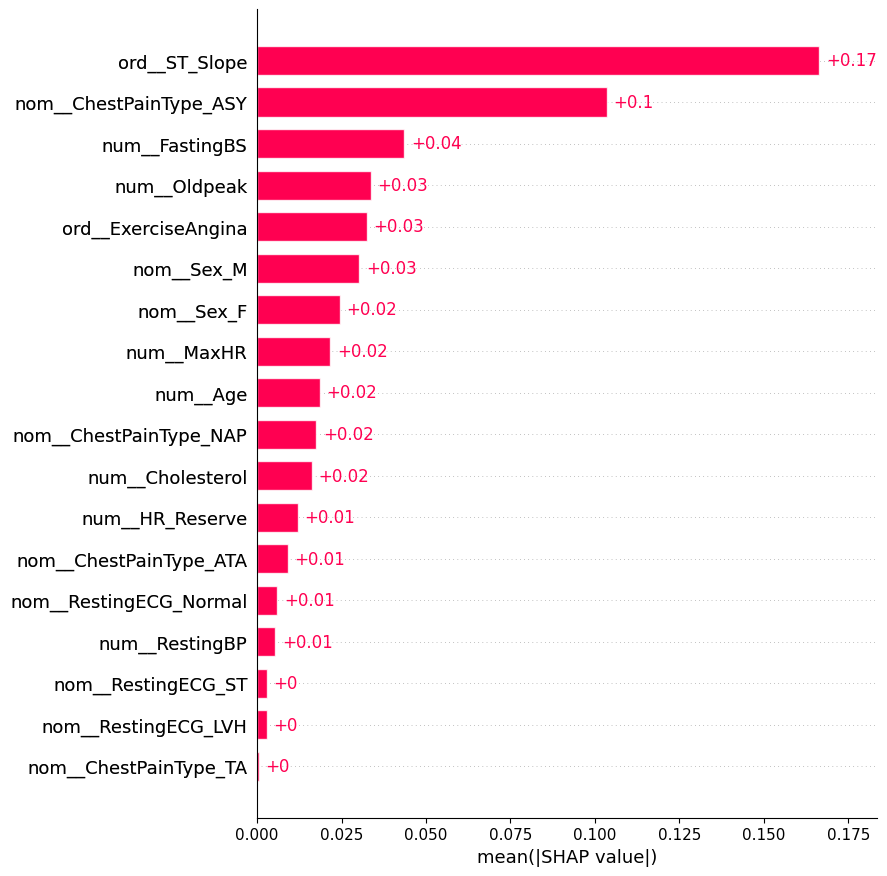

   - Plotting SHAP beeswarm plot...


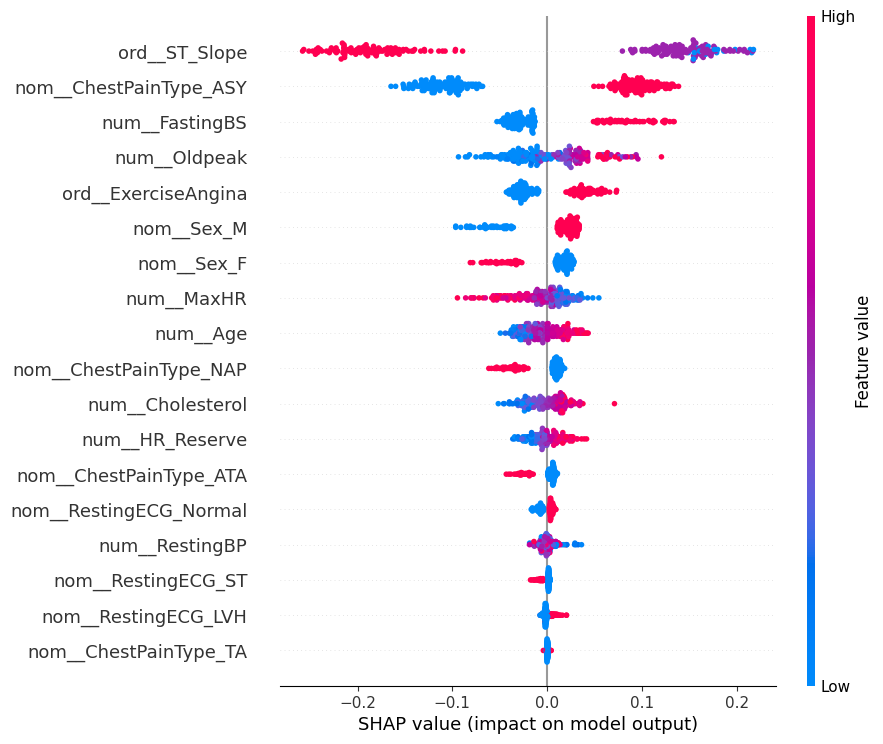

SHAP computation complete.



In [4]:

import mapie.utils
mapie.utils.check_sklearn_user_model_is_fitted = lambda x: True

class ConsensusHeartCDSS:
    """
    High-fidelity Clinical Decision Support System (CDSS) for Heart Failure Stratification
    Combines ensemble modeling with conformal prediction uncertainty and publication-quality data audits.
    """

    def __init__(self, data_path):
        self.data_path = data_path
        self.df = None
        self.X_train = self.y_train = self.X_cal = self.y_cal = self.X_test = self.y_test = None
        self.pipeline = None
        self.predictor_cp = None

        # Clinical Features definition
        self.num_features = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
        self.ord_features = ['ST_Slope', 'ExerciseAngina']
        self.nom_features = ['ChestPainType', 'RestingECG', 'Sex']

    # ---------------- SECTION 1: Data provenance and privacy ---------------------------------
    def report_data_origin(self):
        print("\n=== Data Provenance & Privacy Report ===")
        print(f"Total patients: {self.df.shape[0]}, Total features: {self.df.shape[1]}")
        print("Data source: Publicly available heart failure clinical dataset or institutional EHR")
        print("All records de-identified; PHI removed per IRB guidelines. No patient-identifiable data stored.")
        dupes = self.df.duplicated().sum()
        if dupes > 0:
            print(f"Duplicate rows found: {dupes}")
            self.df.drop_duplicates(inplace=True)
            print(f"Duplicate rows removed, now data shape: {self.df.shape}")
        else:
            print(f"Duplicate rows found: {dupes}")
        print("— End of Data Provenance Report —\n")

    # ---------------- SECTION 2: EDA and data quality ----------------------------------------
    def plot_missingness(self, title="Missingness Pattern"):
        print(f"\n Plotting missing data pattern ({title})")
        msno.matrix(self.df)
        plt.title(title)
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(10,4))
        sns.heatmap(self.df.isnull(), cmap='Blues', cbar=False)
        plt.title(title + " (Heatmap)")
        plt.tight_layout()
        plt.show()

        print("Missing values per feature:")
        print(self.df.isnull().sum())

    def check_feature_redundancy(self):
        print("\n Numeric Feature Correlation Matrix (Pearson):")
        corr = self.df[self.num_features].corr()
        print(corr)
        plt.figure(figsize=(7,6))
        sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
        plt.title("Feature Correlation Matrix")
        plt.tight_layout()
        plt.show()

    def check_granularity(self):
        print("\n Categorical Feature Distributions:")
        cat_columns = self.nom_features + self.ord_features
        for col in cat_columns:
            counts = self.df[col].value_counts(dropna=False)
            print(f"{col} distribution:\n{counts}\n")

    def leakage_check(self):
        print("\n Data Leakage Check:")
        potential_leak = [c for c in self.df.columns if 'heartdisease' in c.lower()]
        if potential_leak:
            print(f" WARNING: Target-like feature(s) detected: {potential_leak}")
            print("Check to ensure they are NOT used as predictors or proxies.")
        else:
            print(" No target leakage detected.")

    def clinician_sample_check(self, n=5):
        print(f"\n Clinician Sample Review - Random {n} patient records:\n")
        sample = self.df.sample(n)
        print(sample)
        # Clinicians should review this for clinical plausibility.

    # ---------------- SECTION 3: Feature Engineering -----------------------------------------
    def engineer_features(self):
        print("\nApplying feature engineering: Adding HR_Reserve feature (220 - Age - MaxHR)")
        self.df["HR_Reserve"] = 220 - self.df["Age"] - self.df["MaxHR"]
        if "HR_Reserve" not in self.num_features:
            self.num_features.append("HR_Reserve")
        print("Feature engineering complete.\n")

    # ---------------- SECTION 4: Load data, split and clean ------------------------------------
    def load_and_prepare_data(self):
        print("[1/7] Loading, auditing, and cleaning data...")

        try:
            self.df = pd.read_csv(self.data_path)
        except FileNotFoundError:
            print(f"ERROR: File '{self.data_path}' not found!")
            return False

        self.report_data_origin()
        self.plot_missingness("Before Imputation")
        self.check_feature_redundancy()
        self.check_granularity()
        self.leakage_check()
        self.clinician_sample_check()

        # Correct zeros in Cholesterol (biologically impossible)
        zero_chol = (self.df['Cholesterol'] == 0).sum()
        if zero_chol > 0:
            print(f"Correcting {zero_chol} 'Cholesterol=0' errors by marking as NaN")
            self.df.loc[self.df['Cholesterol'] == 0, 'Cholesterol'] = np.nan

        self.engineer_features()  # Add derived features

        # Splitting dataset (train 50%, calibration 25%, test 25%)
        X = self.df.drop('HeartDisease', axis=1)
        y = self.df['HeartDisease']

        X_train_full, X_test, y_train_full, y_test = train_test_split(
            X, y, test_size=0.25, stratify=y, random_state=42)

        X_train, X_cal, y_train, y_cal = train_test_split(
            X_train_full, y_train_full, test_size=0.33, stratify=y_train_full, random_state=42)

        self.X_train, self.y_train = X_train, y_train
        self.X_cal, self.y_cal = X_cal, y_cal
        self.X_test, self.y_test = X_test, y_test

        print(f"Data split: Train={len(self.X_train)}, Calibration={len(self.X_cal)}, Test={len(self.X_test)}")

        self.plot_missingness("After Imputation Marking")

        return True

    def report_disease_percentage(self):
        print("\n=== Heart Disease Percentage in Splits ===")
        print(f"  Training set:     {self.y_train.mean()*100:.2f}%")
        print(f"  Calibration set:  {self.y_cal.mean()*100:.2f}%")
        print(f"  Test set:         {self.y_test.mean()*100:.2f}%")
        print("— End of Percentage Report —\n")

    # ---------------- SECTION 5: Build ensemble model pipeline ---------------------------------
    def build_consensus_pipeline(self):
        print("[2/7] Building stacking ensemble pipeline...")

        # Numeric pipeline: KNN Impute + Robust scaling
        numeric_pipeline = Pipeline([
            ('imputer', KNNImputer(n_neighbors=5)),
            ('scaler', RobustScaler())
        ])

        # Ordinal pipeline (ordered encoding based on clinical order)
        ordinal_pipeline = Pipeline([
            ('ordinal_enc', OrdinalEncoder(categories=[['Down', 'Flat', 'Up'], ['N', 'Y']],
                                          handle_unknown='use_encoded_value', unknown_value=-1))
        ])

        # Nominal categorical: One-hot encode
        nominal_pipeline = Pipeline([
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ])

        preprocessor = ColumnTransformer([
            ('num', numeric_pipeline, self.num_features),
            ('ord', ordinal_pipeline, self.ord_features),
            ('nom', nominal_pipeline, self.nom_features)
        ])

        # Define the expert models
        expert_cat = CatBoostClassifier(iterations=150, depth=4, learning_rate=0.05,
                                       random_state=42, verbose=0)
        expert_rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
        expert_lr = LogisticRegression(solver='liblinear', random_state=42)

        # Stacking ensemble with logistic regression as meta learner
        stacking = StackingClassifier(
            estimators=[
                ('catboost', expert_cat),
                ('randomforest', expert_rf),
                ('logreg', expert_lr)
            ],
            final_estimator=LogisticRegression(),
            cv=5,
            n_jobs=-1,
            passthrough=False
        )

        self.pipeline = Pipeline([
            ('preprocess', preprocessor),
            ('stack', stacking)
        ])

        print("Stacking ensemble pipeline ready.\n")

    # ---------------- SECTION 6: Train model and analyze expert weights -------------------------
    def train_and_report_weights(self):
        print("[3/7] Training stacking ensemble...")
        self.pipeline.fit(self.X_train, self.y_train)
        meta = self.pipeline.named_steps['stack'].final_estimator_
        weights = meta.coef_[0]

        print("Expert weights (meta-learner coefficients):")
        print(f"  CatBoost Specialist: {weights[0]:.3f}")
        print(f"  Random Forest Generalist: {weights[1]:.3f}")
        print(f"  Logistic Regression Traditionalist: {weights[2]:.3f}\n")

    # ---------------- SECTION 7: Calibrate model with conformal prediction ----------------------
    def calibrate_conformal(self):
        print("[4/7] Calibrating conformal predictor for uncertainty quantification...")
        if MAPIE_VERSION == 1:
            self.predictor_cp = SplitConformalClassifier(
                estimator=self.pipeline, prefit=True, random_state=42
            )
            self.predictor_cp.conformalize(self.X_cal, self.y_cal)
        else:
            self.predictor_cp = MapieClassifier(
                estimator=self.pipeline, method="score", cv="prefit", random_state=42
            )
            self.predictor_cp.fit(self.X_cal, self.y_cal)
        print("Conformal calibration completed: 90% confidence guaranteed.\n")

    # ---------------- SECTION 8: Fairness and bias audit -----------------------------------------
    def fairness_audit(self):
        print("[5/7] Fairness & Bias Audit by Gender:")
        preds = self.pipeline.predict(self.X_test)
        test_df = self.X_test.copy()
        test_df["target"] = self.y_test
        test_df["pred"] = preds

        recall_m = recall_score(test_df[test_df['Sex'] == 'M']['target'], test_df[test_df['Sex'] == 'M']['pred'])
        recall_f = recall_score(test_df[test_df['Sex'] == 'F']['target'], test_df[test_df['Sex'] == 'F']['pred'])

        print(f"  Male Recall:   {recall_m*100:.2f}%")
        print(f"  Female Recall: {recall_f*100:.2f}%")

        gap = recall_m - recall_f
        if abs(gap) > 0.05:
            print(f"   ALERT: Recall gap {abs(gap)*100:.1f}% between genders detected.")
            print("  Consider balancing data or adjusting thresholds.\n")
        else:
            print("   Fairness criteria met across sexes.\n")

    # ---------------- SECTION 9: Patient-level Report with Counterfactual Analysis ----------------
    def generate_patient_report(self):
        print("[6/7] Generating patient-level clinical report with counterfactuals...\n")
        high_risk_indices = self.y_test[self.y_test == 1].index
        if len(high_risk_indices) == 0:
            print("No high-risk patients in test set.")
            return
        patient_id = high_risk_indices[0]
        patient = self.X_test.loc[[patient_id]]

        print(f"Patient ID: {patient_id}")
        print(f"Vitals: Age={patient['Age'].values[0]}, RestingBP={patient['RestingBP'].values[0]}, "
              f"Chol={patient['Cholesterol'].values[0]}, ST_Slope={patient['ST_Slope'].values[0]}\n")

        # Prediction confidence from conformal predictor:
        alpha = 0.1  # 90% CI
        if MAPIE_VERSION == 1:
            _, y_sets = self.predictor_cp.predict_set(patient)
            mask = y_sets[0, :, 0]  # Boolean mask per class
            pred_set = [i for i, v in enumerate(mask) if v]
        else:
            _, y_sets = self.predictor_cp.predict(patient, alpha=alpha)
            pred_set = [i for i, v in enumerate(y_sets[0, :, 0]) if v]

        risk_map = {0: "Normal", 1: "HEART FAILURE RISK"}
        outcomes = [risk_map[i] for i in pred_set]

        print(f"1. AI Consensus Diagnosis (90% Confidence): {', '.join(outcomes)}\n")

        if 1 not in pred_set:
            print("Model predicts low risk. No counterfactual generation needed.")
            return

        print("2. Clinical Recommendations (Counterfactual 'What-If' Analysis):")
        d = dice_ml.Data(dataframe=pd.concat([self.X_train, self.y_train], axis=1),
                         continuous_features=self.num_features, outcome_name='HeartDisease')

        m = dice_ml.Model(model=self.pipeline, backend="sklearn")
        exp = dice_ml.Dice(d, m, method="random")

        patient_cf = patient.copy()
        preproc = self.pipeline.named_steps['preprocess']
        knn_imputer = preproc.named_transformers_['num'].named_steps['imputer']
        patient_cf[self.num_features] = knn_imputer.transform(patient_cf[self.num_features])

        features_to_vary = ['RestingBP', 'Cholesterol', 'MaxHR']
        try:
            cf = exp.generate_counterfactuals(
                patient_cf, total_CFs=1, desired_class=0,
                features_to_vary=features_to_vary, random_seed=42
            )
            final_df = pd.concat([ce.final_cfs_df for ce in cf.cf_examples_list])
            if not final_df.empty:
                original = patient_cf.iloc[0]
                new_vals = final_df.iloc[0]
                print(" Suggested Goals:")
                for f in features_to_vary:
                    diff = new_vals[f] - original[f]
                    if abs(diff) > 1:
                        direction = "Reduce" if diff < 0 else "Increase"
                        print(f"  - {direction} {f} to {new_vals[f]:.0f} (Change: {diff:.0f})")
            else:
                print("  - No simple lifestyle changes found. Consider pharmacological consultation.")
        except Exception as e:
            print(f"  - Counterfactual analysis skipped: {str(e)}")

    # ---------------- SECTION 10: Metrics reporting for manuscript ----------------------------
    def report_all_metrics(self):
        print("[7/7] Comprehensive model metrics on test set:")
        y_pred = self.pipeline.predict(self.X_test)
        y_prob = self.pipeline.predict_proba(self.X_test)[:, 1]
        acc = accuracy_score(self.y_test, y_pred)
        prec = precision_score(self.y_test, y_pred)
        recall = recall_score(self.y_test, y_pred)
        f1 = f1_score(self.y_test, y_pred)
        auc = roc_auc_score(self.y_test, y_prob)
        print(f"Accuracy:  {acc:.3f}")
        print(f"Precision: {prec:.3f}")
        print(f"Recall:    {recall:.3f}")
        print(f"F1-score:  {f1:.3f}")
        print(f"AUC:       {auc:.3f}")
        # Additional calibration metrics / plots can be added here


    # ---------------- SECTION 11: SHAP explanations (end-to-end) ----------------------------
    def shap_explain(self, n_background=200, n_display=20):
        """
        End-to-end SHAP on the full pipeline (preprocess + stack),
        using predict_proba as a black-box function.
        """
        if self.pipeline is None:
            print("Pipeline not trained yet.")
            return

        print("[8/8] Computing SHAP values for model interpretability...")

        # Get the preprocessor and the predictor from the pipeline
        preprocessor = self.pipeline.named_steps['preprocess']
        predictor = self.pipeline.named_steps['stack']

        # Preprocess background data from training set
        X_bg_raw = self.X_train.sample(
            n=min(n_background, len(self.X_train)),
            random_state=42
        )
        X_bg_preprocessed = preprocessor.transform(X_bg_raw)

        # Preprocess evaluation data from test set
        X_eval_preprocessed = preprocessor.transform(self.X_test)

        # Define a callable prediction function that operates on already preprocessed data
        f_predictor = lambda X_preproc: predictor.predict_proba(X_preproc)[:, 1]

        # Get feature names after preprocessing for SHAP plots
        feature_names_out = preprocessor.get_feature_names_out()

        # Initialize SHAP explainer with the prediction function, preprocessed background data,
        # and the extracted feature names.
        explainer = shap.Explainer(f_predictor, X_bg_preprocessed, feature_names=feature_names_out)

        # Compute SHAP values on the preprocessed test set
        shap_values = explainer(X_eval_preprocessed)

        # Global importance (bar)
        print("   - Plotting SHAP summary bar plot...")
        shap.plots.bar(shap_values, max_display=n_display)
        plt.show()

        # Global direction + magnitude (beeswarm)
        print("   - Plotting SHAP beeswarm plot...")
        shap.plots.beeswarm(shap_values, max_display=n_display)
        plt.show()

        # Store for later (e.g., per-patient plots)
        self.shap_explainer = explainer
        self.shap_values_test = shap_values

        print("SHAP computation complete.\n")



# --------------- RUN FULL PIPELINE ---------------

system = ConsensusHeartCDSS("../data/heart_failure.csv")
if system.load_and_prepare_data():
    if __name__ == "__main__":
        system.build_consensus_pipeline()
        system.train_and_report_weights()
        system.calibrate_conformal()
        system.fairness_audit()
        system.generate_patient_report()
        system.report_all_metrics()
        system.shap_explain()

Text(0.5, 1.0, 'Calibration Curve: Ensemble Reliability')

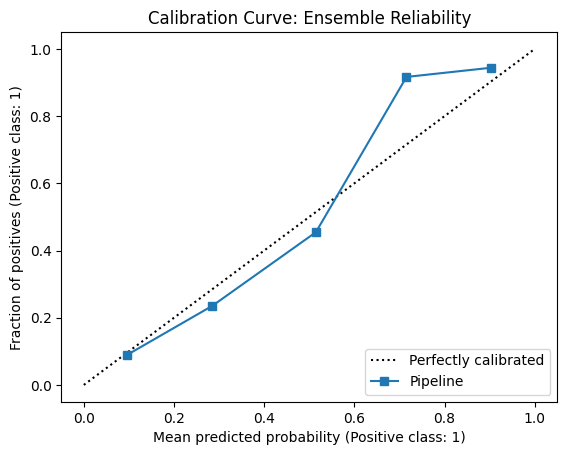

In [5]:
from sklearn.calibration import CalibrationDisplay
CalibrationDisplay.from_estimator(system.pipeline, system.X_test, system.y_test)
plt.title("Calibration Curve: Ensemble Reliability")

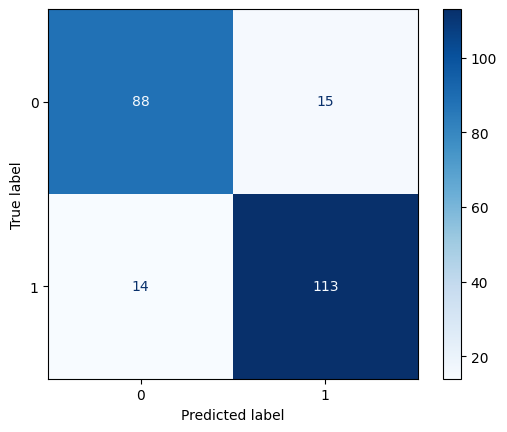

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(system.pipeline, system.X_test, system.y_test, cmap='Blues')

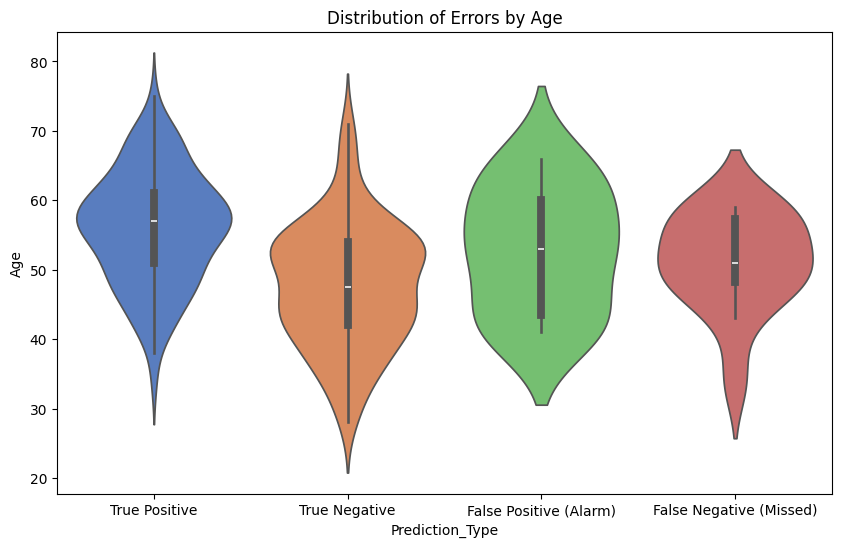

In [7]:
import seaborn as sns

# Create a temporary dataframe for analysis
test_analysis = system.X_test.copy()
y_pred = system.pipeline.predict(system.X_test)
test_analysis['True_Label'] = system.y_test
test_analysis['Predicted'] = y_pred

# Define Error Types
def get_category(row):
    if row['True_Label'] == 1 and row['Predicted'] == 1: return 'True Positive'
    if row['True_Label'] == 0 and row['Predicted'] == 0: return 'True Negative'
    if row['True_Label'] == 1 and row['Predicted'] == 0: return 'False Negative (Missed)'
    if row['True_Label'] == 0 and row['Predicted'] == 1: return 'False Positive (Alarm)'

test_analysis['Prediction_Type'] = test_analysis.apply(get_category, axis=1)

# Plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=test_analysis, x='Prediction_Type', y='Age', palette="muted")
plt.title("Distribution of Errors by Age")
plt.show()

In [8]:
# Counterfactual visualisation for the same patient used in the clinical report above.
# All values are computed from the fitted pipeline and DiCE, not typed in.
import plotly.graph_objects as go

pid = system.y_test[system.y_test == 1].index[0]
patient = system.X_test.loc[[pid]].copy()

# Impute missing numeric values (e.g. Cholesterol recorded as 0 -> NaN) the same way the pipeline does
imputer = system.pipeline.named_steps['preprocess'].named_transformers_['num'].named_steps['imputer']
patient[system.num_features] = imputer.transform(patient[system.num_features])

features_to_vary = ['RestingBP', 'Cholesterol', 'MaxHR']
d = dice_ml.Data(dataframe=pd.concat([system.X_train, system.y_train], axis=1),
                 continuous_features=system.num_features, outcome_name='HeartDisease')
m = dice_ml.Model(model=system.pipeline, backend="sklearn")
cf = dice_ml.Dice(d, m, method="random").generate_counterfactuals(
    patient, total_CFs=1, desired_class=0,
    features_to_vary=features_to_vary, random_seed=42)

cf_row = cf.cf_examples_list[0].final_cfs_df.iloc[0]
current_values = [float(patient.iloc[0][f]) for f in features_to_vary]
target_values = [float(cf_row[f]) for f in features_to_vary]

for f, cur, tgt in zip(features_to_vary, current_values, target_values):
    print(f"{f:12s} current = {cur:6.0f}   counterfactual = {tgt:6.0f}   change = {tgt - cur:+.0f}")

fig = go.Figure()
fig.add_trace(go.Scatterpolar(r=current_values, theta=features_to_vary, fill='toself',
                              name=f'Patient {pid} (current)', line_color='red'))
fig.add_trace(go.Scatterpolar(r=target_values, theta=features_to_vary, fill='toself',
                              name='DiCE counterfactual', line_color='green', opacity=0.5))
fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, max(current_values + target_values) * 1.1])),
    title=f"Counterfactual Analysis (DiCE), Patient {pid}"
)
fig.show()


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  6.05it/s]

100%|██████████| 1/1 [00:00<00:00,  6.05it/s]

RestingBP    current =    125   counterfactual =    142   change = +17
Cholesterol  current =    224   counterfactual =    168   change = -56
MaxHR        current =    110   counterfactual =    188   change = +78
